#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

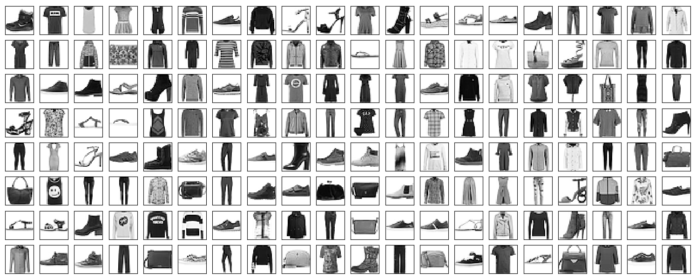


In [16]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

In [3]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

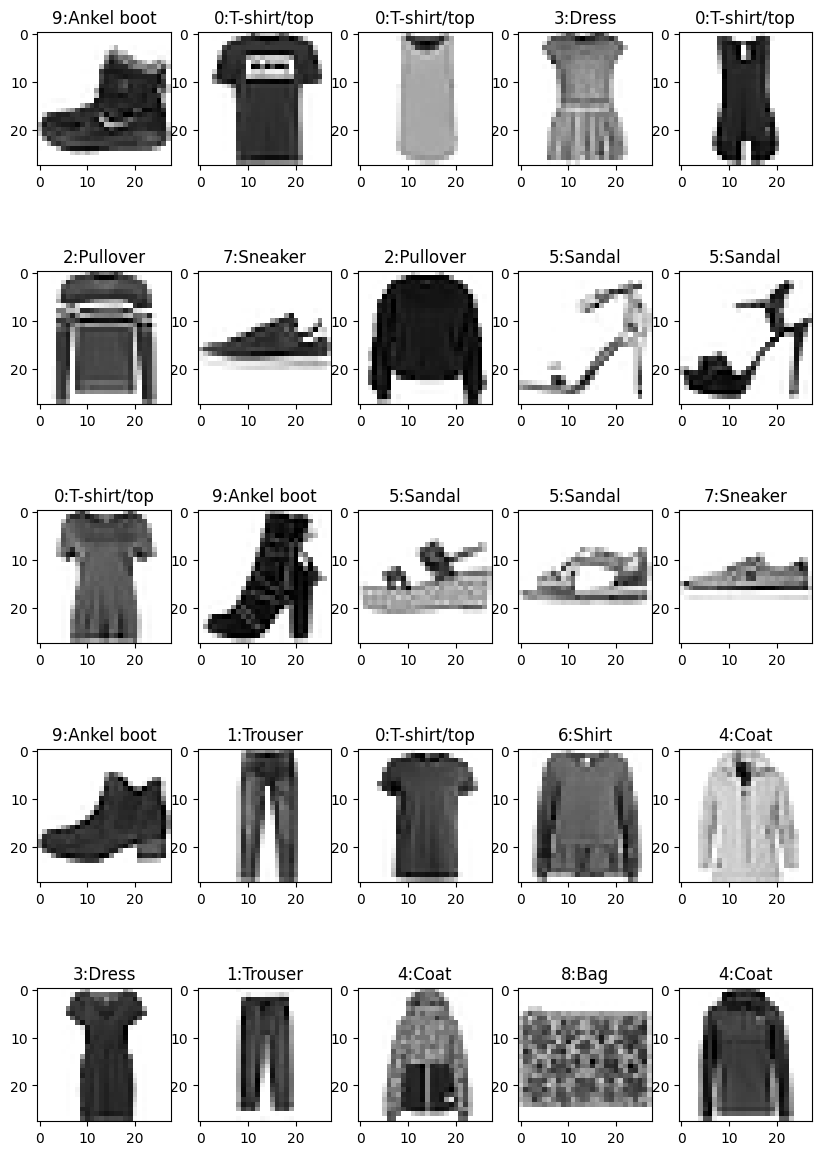

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [6]:
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [7]:
x_train = x_train / 255
x_test = x_test / 255

#모델구성

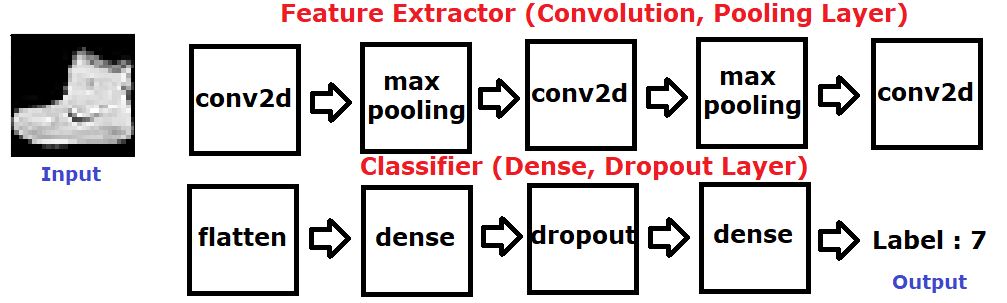

## Feature Extractor

In [8]:
model =models.Sequential()
model.add(layers.Conv2D(32, (3,3), padding='same',activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2),strides=2)) #일반적으로 strides는 커널 크기(2,2)와 동일하게 설정하여 겹치지 않도록 함
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2),strides=2))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.Flatten()) #2차원 이상의 데이터를 1차원으로 변환하는 레이어
model.add(layers.Dense(128, activation='relu')) #128개의 뉴런을 가진 완전 연결층, 활성화 함수는 relu
model.add(layers.Dropout(0.3)) #과적합 방지 위해 Dropout 레이어 추가, 0.3는 30%의 뉴런을 무작위로 끔
model.add(layers.Dense(10, activation='softmax')) #10개의 뉴런을 가진 완전 연결층, 활성화 함수는 softmax, 출력층
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8279 - loss: 0.4812 - val_accuracy: 0.8855 - val_loss: 0.3062
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8895 - loss: 0.3032 - val_accuracy: 0.9033 - val_loss: 0.2680
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9072 - loss: 0.2554 - val_accuracy: 0.9076 - val_loss: 0.2537
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9192 - loss: 0.2225 - val_accuracy: 0.9143 - val_loss: 0.2288
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9289 - loss: 0.1931 - val_accuracy: 0.9179 - val_loss: 0.2208
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9363 - loss: 0.1707 - val_accuracy: 0.9204 - val_loss: 0.2250
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9446 - loss: 0.1497 - val_accuracy: 0.9249 - val_loss: 0.2281
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9509 - loss: 0.1302 -

### Classifier

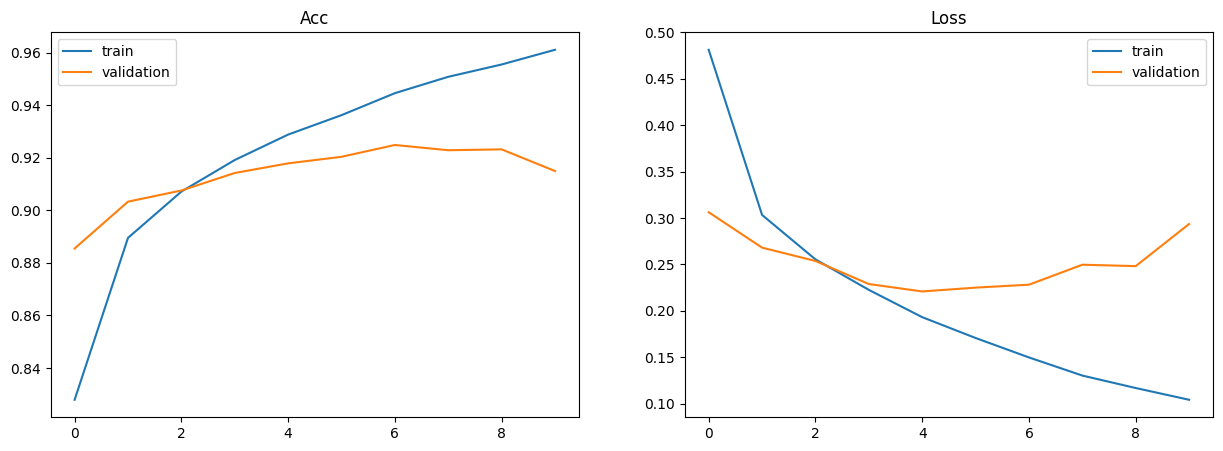

In [19]:
def plot_history(history):
    plt.figure(figsize=(15,5))

    plt.subplot(1,2,1)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.legend(['train','validation'])
    plt.title('Acc')

    plt.subplot(1,2,2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.legend(['train','validation'])
    plt.title('Loss')

    plt.show()
plot_history(history.history)

# Drop out<br>
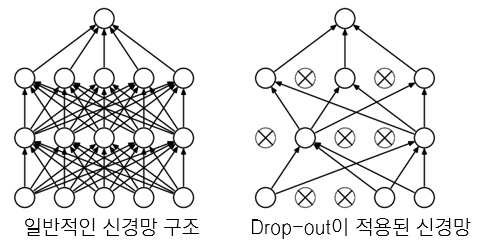

## BatchNormalization
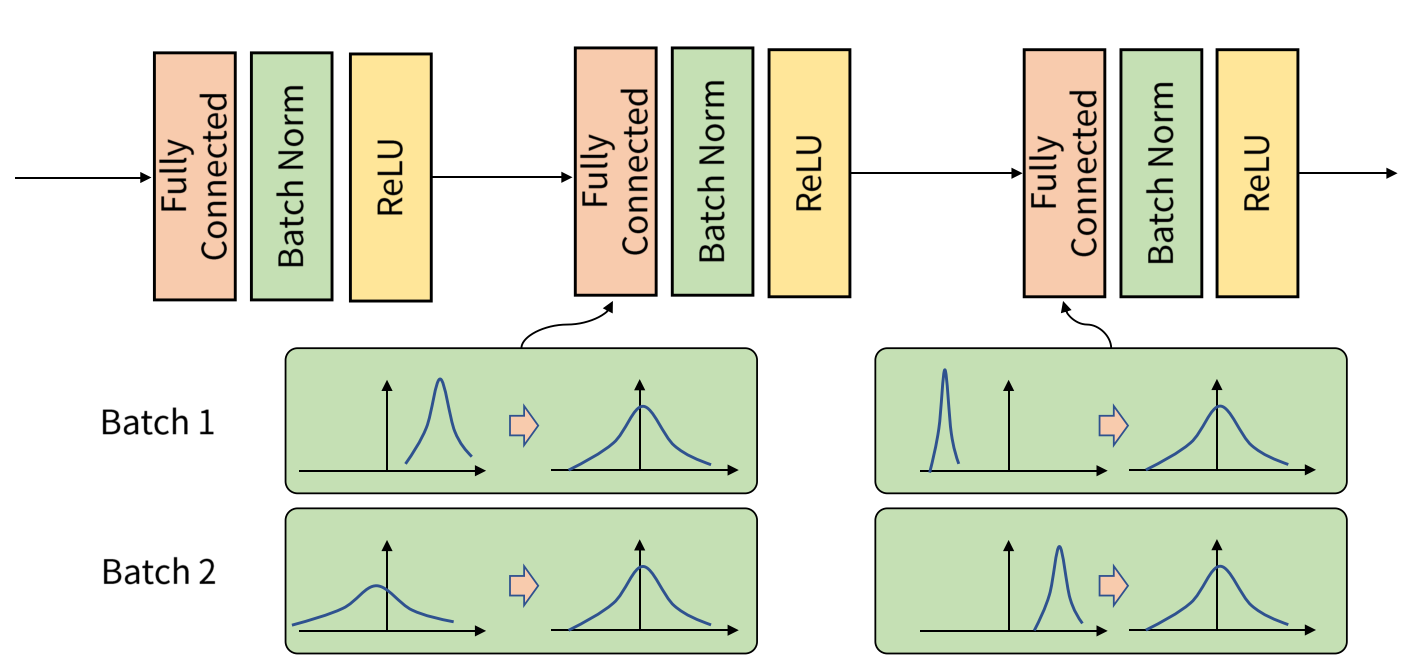

In [ ]:
model2 =models.Sequential()
model2.add(layers.Conv2D(32, (3,3), padding='same',activation='relu', input_shape=(28,28,1)))
model2.add(layers.BatchNormalization()) #배치 정규화 레이어 추가, 각 배치마다 입력을 정규화하여 학습 안정성과 속도 향상, 과적합 방지에도 도움
model2.add(layers.MaxPooling2D((2,2),strides=2)) #일반적으로 strides는 커널 크기(2,2)와 동일하게 설정하여 겹치지 않도록 함
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2),strides=2))
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(layers.Flatten()) #2차원 이상의 데이터를 1차원으로 변환하는 레이어
model2.add(layers.Dense(128, activation='relu')) #128개의 뉴런을 가진 완전 연결층, 활성화 함수는 relu
model2.add(layers.Dropout(0.3)) #과적합 방지 위해 Dropout 레이어 추가, 0.3는 30%의 뉴런을 무작위로 끔
model2.add(layers.Dense(10, activation='softmax')) #10개의 뉴런을 가진 완전 연결층, 활성화 함수는 softmax, 출력층
model2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

## Callback

In [12]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

NameError: name 'model3' is not defined

In [ ]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

## CNN의 시각화

### 학습된 Conv층 가져오기

### 필터를 거친 이미지 확인하기